# Visualize generative performance with real dataset 

In [1]:
import pandas as pd
import torch
import os
import sys
from pathlib import Path
module_path = Path.cwd().parent / 'utils'
sys.path.append(str(module_path))
import data_processing, visualization
module_path = Path.cwd().parent / 'execute'
sys.path.append(str(module_path))

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

## 1. Original data loading, analysis and visualization

### 1.1. Experiment setting - links to data

In [2]:
dataset_name = "ACTG320"
current_path = os.getcwd()  # Get current working directory
parent_path = os.path.dirname(current_path)
data_file_control= parent_path + "/dataset/" + dataset_name + "/data_control.csv"
feat_types_file_control = parent_path + "/dataset/" + dataset_name + "/data_types_control.csv"
data_file_treated= parent_path + "/dataset/" + dataset_name + "/data_treated.csv"
feat_types_file_treated= parent_path + "/dataset/" + dataset_name + "/data_types_treated.csv"

# If the dataset has no missing data, leave the "miss_file" variable empty
m_perc = 10
mask = 1
miss_file = "dataset/" + dataset_name + "/Missing{}_{}.csv".format(m_perc, mask)
true_miss_file = None

### 1.2. Loading, feature analysis, and visualization of original data: control vs treated group

In [3]:
control_fnames = ['time', 'censor'] + pd.read_csv(feat_types_file_control)["name"].to_list()[1:]
control = pd.read_csv(data_file_control, header=None, names=control_fnames)
print(control.head())

   time  censor  strat2  sex  raceth  ivdrug  karnof    cd4  priorzdv  age
0   189       0       1    0       1       0     100  169.0      39.0   34
1   287       0       1    1       2       0      90  149.5      15.0   34
2   199       0       1    0       1       0      90   46.0      53.0   48
3   270       0       1    0       2       0     100   54.5       6.0   51
4   276       0       1    0       1       0     100   95.0       7.0   34


In [4]:
# Load and transform control data
df_init_control_encoded, feat_types_dict, miss_mask_control, true_miss_mask_control, _, dict_cat_map_control = data_processing.read_data(data_file_control, feat_types_file_control, miss_file,
                                                                                                                                          true_miss_file, return_cat_mapping=True)
data_init_control_encoded = torch.from_numpy(df_init_control_encoded.values)
data_init_control = data_processing.discrete_variables_transformation(data_init_control_encoded, feat_types_dict)

# Load and transform treated data
df_init_treated_encoded, _, _, _, _ = data_processing.read_data(data_file_treated, feat_types_file_treated, miss_file, true_miss_file)
data_init_treated_encoded = torch.from_numpy(df_init_treated_encoded.values)
data_init_treated = data_processing.discrete_variables_transformation(data_init_treated_encoded, feat_types_dict)

In [5]:
# Format data in dataframe
df_init_treated = pd.DataFrame(data_init_treated.numpy(), columns=control_fnames)
df_init_control = pd.DataFrame(data_init_control.numpy(), columns=control_fnames)

# Update dataframe
df_init_treated["treatment"] = 1
df_init_control["treatment"] = 0
df_init = pd.concat([df_init_control, df_init_treated], ignore_index=True)

In [6]:
continuous = [row['name'] for row in feat_types_dict if row['type'] in ['pos', 'real']]
categorical = [row['name'] for row in feat_types_dict if row['type'] in ['cat']]

## 2. Training and generation from the generative model

### 2.1. 100% of the dataset

Possible generative models: HI-VAE (our), survival_gan, survival_ctgan, survival_nflow, survae (synthcity)

In [7]:
import surv_hivae, surv_gan, surv_vae
generators_dict = {"HI-VAE_weibull" : surv_hivae,
                    "HI-VAE_piecewise" : surv_hivae,
                    "Surv-GAN" : surv_gan,
                    "Surv-VAE" : surv_vae}



[KeOps] Warning : No C++ compiler found. Define CXX environment variable or install g++.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : No C++ compiler available to check for OpenMP support.
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


In [ ]:
# the datasets used for training is data_init_control
import json
import os
name_config = "aug_Ncontrol3%3_ntrials150_DetectXGB"
# best_param_files = [f for f in os.listdir("optuna_results") if (f.endswith('.json') & (name_config in f))]

generators_sel = ["HI-VAE_weibull", "HI-VAE_piecewise", "Surv-GAN", "Surv-VAE"]

best_params_dict = {}
for generator_name in generators_sel:
    # best_param_file = [item for item in best_param_files if generator_name in item][0]
    for f in os.listdir(parent_path + "/dataset/" + dataset_name + "/optuna_results"):
        if (f.endswith(generator_name + '.json') & (dataset_name in f) & (name_config in f)):
            best_param_file = f
    with open(parent_path + "/dataset/" + dataset_name + "/optuna_results/" + best_param_file, "r") as f:
        best_params_dict[generator_name] = json.load(f)

n_generated_dataset = 100
data_gen_control_dict = {}
for generator_name in generators_sel:
    print("=" * 100)
    print("Generate data by " + generator_name)
    best_params = best_params_dict[generator_name]
    if generator_name in ["HI-VAE_weibull", "HI-VAE_piecewise"]:
            feat_types_dict_ext = feat_types_dict.copy()
            for i in range(len(feat_types_dict)):
                if feat_types_dict_ext[i]['name'] == "survcens":
                    if generator_name in["HI-VAE_weibull"]:
                        feat_types_dict_ext[i]["type"] = 'surv_weibull'
                    else:
                        feat_types_dict_ext[i]["type"] = 'surv_piecewise'
    if generator_name in ["HI-VAE_weibull", "HI-VAE_piecewise"]:
        data_gen_control_dict[generator_name] = generators_dict[generator_name].run(df_init_control_encoded, miss_mask_control, true_miss_mask_control, feat_types_dict_ext, n_generated_dataset, params=best_params, epochs = 10000, apply_rounding=True)
    else:
        data_gen_control_dict[generator_name] = generators_dict[generator_name].run(data_init_control, columns=control_fnames, target_column="censor", time_to_event_column="time", n_generated_dataset=n_generated_dataset, params=best_params, apply_rounding=True)

Generate data by HI-VAE_weibull
Epoch: [ 0]  time: 0.4894, ELBO_train: -24.21410561, KL_z: 4.76292010, KL_s: 0.02897014, reconstruction loss: -19.42221536
Epoch: [100]  time: 12.6008, ELBO_train: -16.73820432, KL_z: 0.65999543, KL_s: 0.73202244, reconstruction loss: -15.34618645
Epoch: [200]  time: 24.6873, ELBO_train: -17.30945142, KL_z: 0.94219807, KL_s: 0.13285393, reconstruction loss: -16.23439942
Epoch: [300]  time: 37.0178, ELBO_train: -17.06299432, KL_z: 1.42371434, KL_s: 0.01328232, reconstruction loss: -15.62599766
Epoch: [400]  time: 49.4342, ELBO_train: -16.98873234, KL_z: 1.64888942, KL_s: 0.01459774, reconstruction loss: -15.32524518
Epoch: [500]  time: 61.9052, ELBO_train: -17.02161058, KL_z: 1.76162352, KL_s: 0.00823380, reconstruction loss: -15.25175326
Epoch: [600]  time: 74.7129, ELBO_train: -16.91538556, KL_z: 1.87011021, KL_s: 0.01210452, reconstruction loss: -15.03317083
Epoch: [700]  time: 86.8169, ELBO_train: -16.96059227, KL_z: 2.04098554, KL_s: 0.01430578, reco

[2026-07-25T17:11:15.441235+0200][27504][CRITICAL] Error importing TabularGoggle: No module named 'dgl'
[2026-07-25T17:11:15.445867+0200][27504][CRITICAL] module disabled: c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\site-packages\synthcity\plugins\generic\plugin_goggle.py
  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\subprocess.py", line 1540, in _execut

Generate data by Surv-VAE


100%|██████████| 500/500 [06:10<00:00,  1.35it/s]


In [9]:
# Convert generated data into dataframe
dict_model_generated_data = {}
df_syn_dict = {}
for generator_name in generators_sel:
    list_df_gen_control = []
    data_syn = []
    for j in range(n_generated_dataset):
        df_gen_control_j = pd.DataFrame(data_gen_control_dict[generator_name][j].numpy(), columns=control_fnames)
        df_gen_control_j['treatment'] = 0
        list_df_gen_control.append(df_gen_control_j)
        data_syn.append(pd.concat([df_init_treated, df_gen_control_j], ignore_index=True))
    list_df_gen_control_recoded = [
        data_processing.decode_categoricals(df, dict_cat_map_control)
        for df in list_df_gen_control]
    dict_model_generated_data[generator_name] = list_df_gen_control_recoded
    df_syn_dict[generator_name] = data_syn

### 2.2. 67% of the dataset

In [ ]:
# In order to run a membership inference attack on real data, we need to decompose the initial set in a train vs holdout set.

import numpy as np

list_indexes_train = list(np.random.choice(len(df_init_control), size=int(2/3 * len(df_init_control)), replace=False))

data_init_control_train = data_init_control[data_init_control.index.isin(list_indexes_train)].reset_index(drop=True)

df_init_control_train = df_init_control[df_init_control.index.isin(list_indexes_train)].reset_index(drop=True)
df_init_control_holdout = df_init_control[~df_init_control.index.isin(list_indexes_train)].reset_index(drop=True)

df_init_control_encoded_train = df_init_control_encoded[df_init_control_encoded.index.isin(list_indexes_train)].reset_index(drop=True)

NameError: name 'np' is not defined

In [ ]:
# the datasets used for training is data_init_control_train
import json
import os
name_config_aug = "aug_Ncontrol2%3_ntrials150_DetectXGB"

best_params_dict_aug = {}
for generator_name in generators_sel:
    # best_param_file = [item for item in best_param_files if generator_name in item][0]
    for f in os.listdir(parent_path + "/dataset/" + dataset_name + "/optuna_results"):
        if (f.endswith(generator_name + '.json') & (dataset_name in f) & (name_config_aug in f)):
            best_param_file = f
    with open(parent_path + "/dataset/" + dataset_name + "/optuna_results/" + best_param_file, "r") as f:
        best_params_dict_aug[generator_name] = json.load(f)

n_generated_dataset = 100
data_gen_control_dict_aug = {}
for generator_name in generators_sel:
    print("=" * 100)
    print("Generate data by " + generator_name)
    best_params = best_params_dict_aug[generator_name]
    if generator_name in ["HI-VAE_weibull", "HI-VAE_piecewise"]:
            feat_types_dict_ext = feat_types_dict.copy()
            for i in range(len(feat_types_dict)):
                if feat_types_dict_ext[i]['name'] == "survcens":
                    if generator_name in["HI-VAE_weibull"]:
                        feat_types_dict_ext[i]["type"] = 'surv_weibull'
                    else:
                        feat_types_dict_ext[i]["type"] = 'surv_piecewise'
    if generator_name in ["HI-VAE_weibull", "HI-VAE_piecewise"]:
        data_gen_control_dict_aug[generator_name] = generators_dict[generator_name].run(df_init_control_encoded_train, miss_mask_control[list_indexes_train], true_miss_mask_control[list_indexes_train], feat_types_dict_ext,n_generated_sample=len(df_init_control), n_generated_dataset=n_generated_dataset, params=best_params, epochs = 10000, apply_rounding=True)
    else:
        data_gen_control_dict_aug[generator_name] = generators_dict[generator_name].run(data_init_control_train, columns=control_fnames, target_column="censor", time_to_event_column="time", n_generated_sample=len(df_init_control), n_generated_dataset=n_generated_dataset, params=best_params, feat_types_dict=feat_types_dict, apply_rounding=True)

In [ ]:
# Convert generated data into dataframe
dict_model_generated_data_aug = {}
for generator_name in generators_sel:
    list_df_gen_control = []
    for j in range(n_generated_dataset):
        df_gen_control_j = pd.DataFrame(data_gen_control_dict_aug[generator_name][j].numpy(), columns=control_fnames)
        df_gen_control_j['treatment'] = 0
        list_df_gen_control.append(df_gen_control_j)
    list_df_gen_control_recoded = [
        data_processing.decode_categoricals(df, dict_cat_map_control)
        for df in list_df_gen_control]
    dict_model_generated_data_aug[generator_name] = list_df_gen_control_recoded

### 3. Compare generation performance

#### 3.1. General metrics

In [ ]:
from metrics import general_metrics_modular
simple_score_metrics = {'stats': ['jensenshannon_dist', 'survival_km_distance'],
                        'detection': ['detection_xgb'],
                        'privacy': ['k-map', 'identifiability_score']}

general_scores_full = []
general_scores_aug = []
general_scores_all = []
for generator_name in generators_sel:
    scores_full = general_metrics_modular(data_processing.decode_categoricals(df_init_control, dict_cat_map_control), dict_model_generated_data[generator_name], 
                                                   generator_name, simple_score_metrics, include_nndr=True, include_tableone_min_p_value=True,
                                                    categorical=categorical, continuous=continuous,
                                                    nonnormal=continuous)
    general_scores_full.append(scores_full.copy())
    scores_full['aug_pct'] = 1
    scores_full['dataset_name'] = dataset_name

    scores_aug = general_metrics_modular(data_processing.decode_categoricals(df_init_control, dict_cat_map_control), dict_model_generated_data_aug[generator_name], 
                                                   generator_name, simple_score_metrics, include_nndr=True, include_tableone_min_p_value=True,
                                                    categorical=categorical, continuous=continuous,
                                                    nonnormal=continuous)
    general_scores_aug.append(scores_aug.copy())
    scores_aug['aug_pct'] = 2/3
    scores_aug['dataset_name'] = dataset_name

    general_scores_all.append(pd.concat([scores_full, scores_aug], ignore_index=True))
    
general_scores_full_df = pd.concat(general_scores_full)
general_scores_aug_df = pd.concat(general_scores_aug)
general_scores_all_df = pd.concat(general_scores_all, ignore_index=True)

##### 3.1.1. Data resemblance

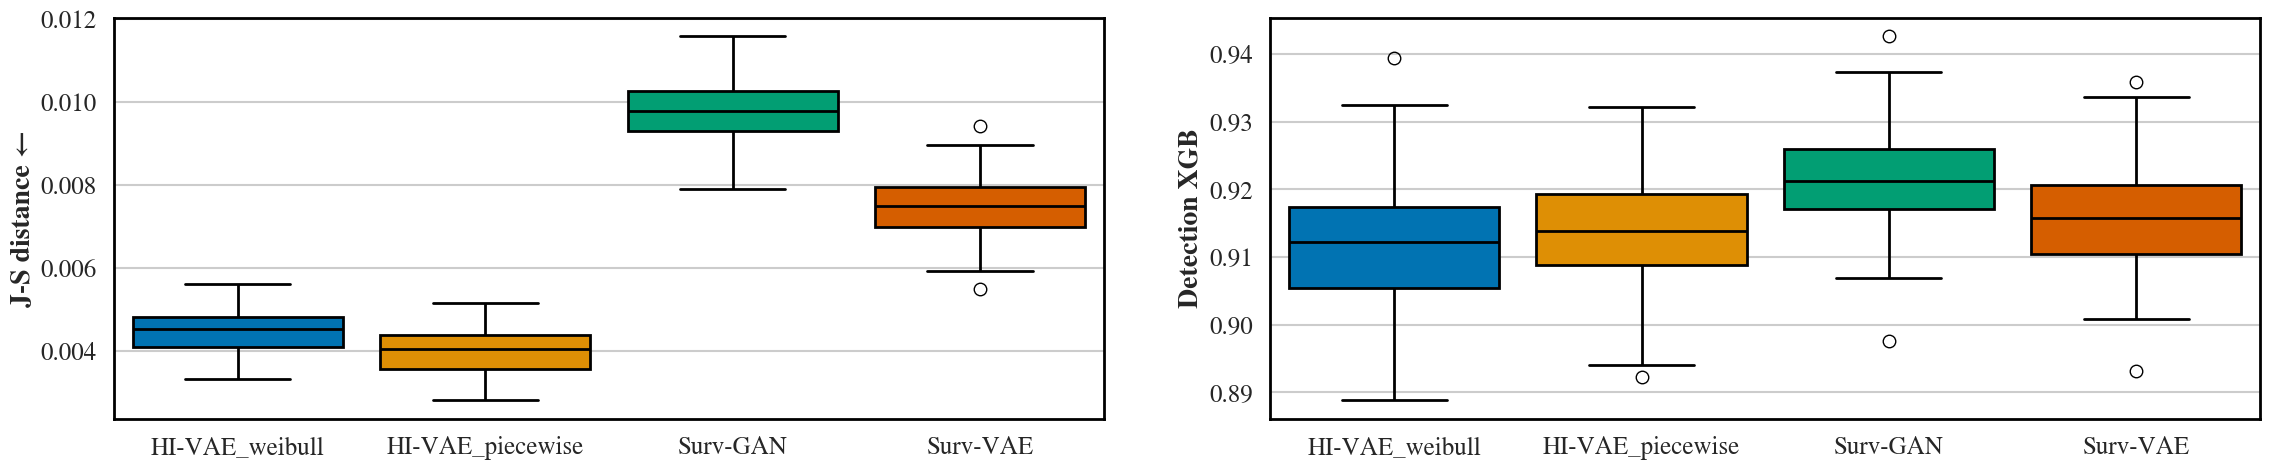

In [ ]:
from visualization import visualize_general_perf

fidelity_metrics = [['J-S distance', "min"], ['Detection XGB', 0.5]]

visualize_general_perf(general_scores_full_df, metrics=fidelity_metrics, title = "Data sharing case")

visualize_general_perf(general_scores_aug_df, metrics=fidelity_metrics, title = "Data augmentation case")

##### 3.1.2. Utility

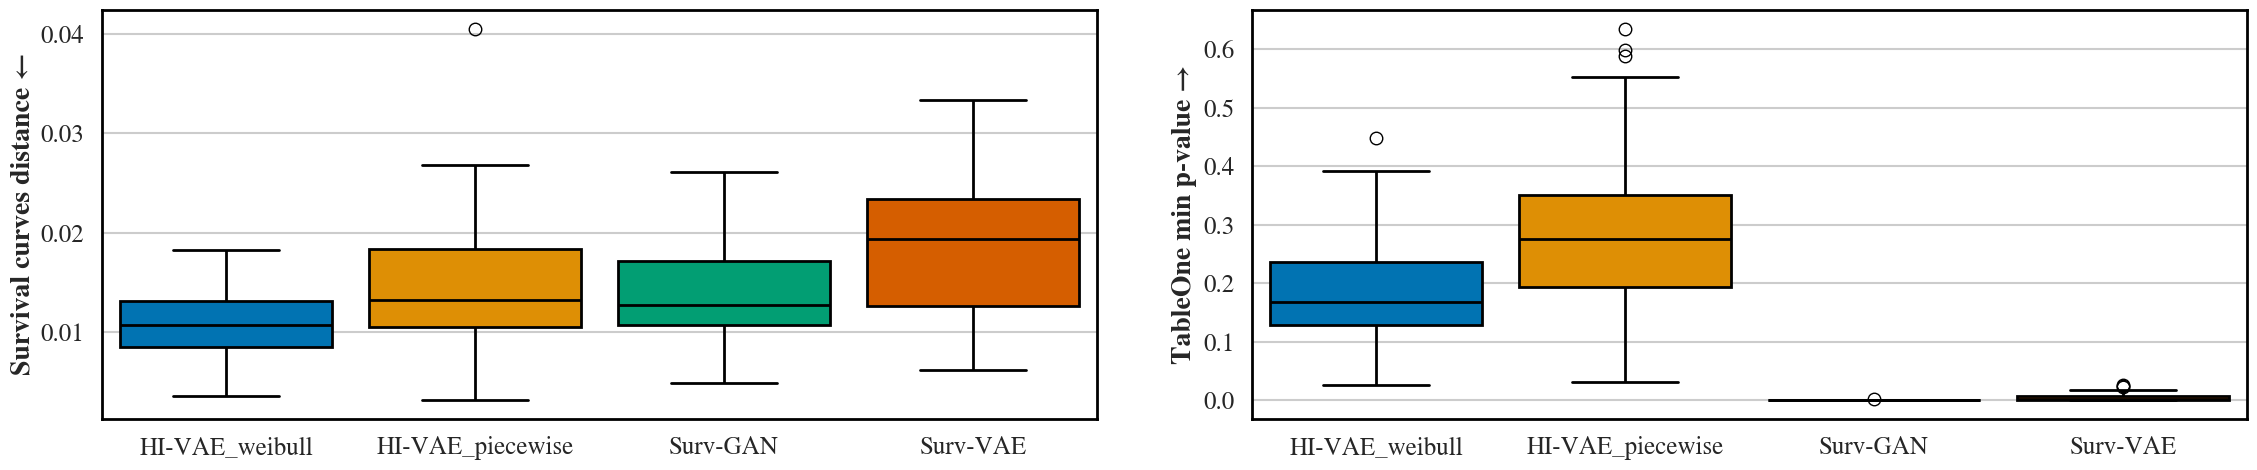

In [ ]:
utility_metrics = [['Survival curves distance', "min"], ['TableOne min p-value', "max"]]

visualize_general_perf(general_scores_full_df, metrics=utility_metrics, title = "Data sharing case")

visualize_general_perf(general_scores_aug_df, metrics= utility_metrics, title = "Data augmentation case")

#### 3.1.3. Privacy

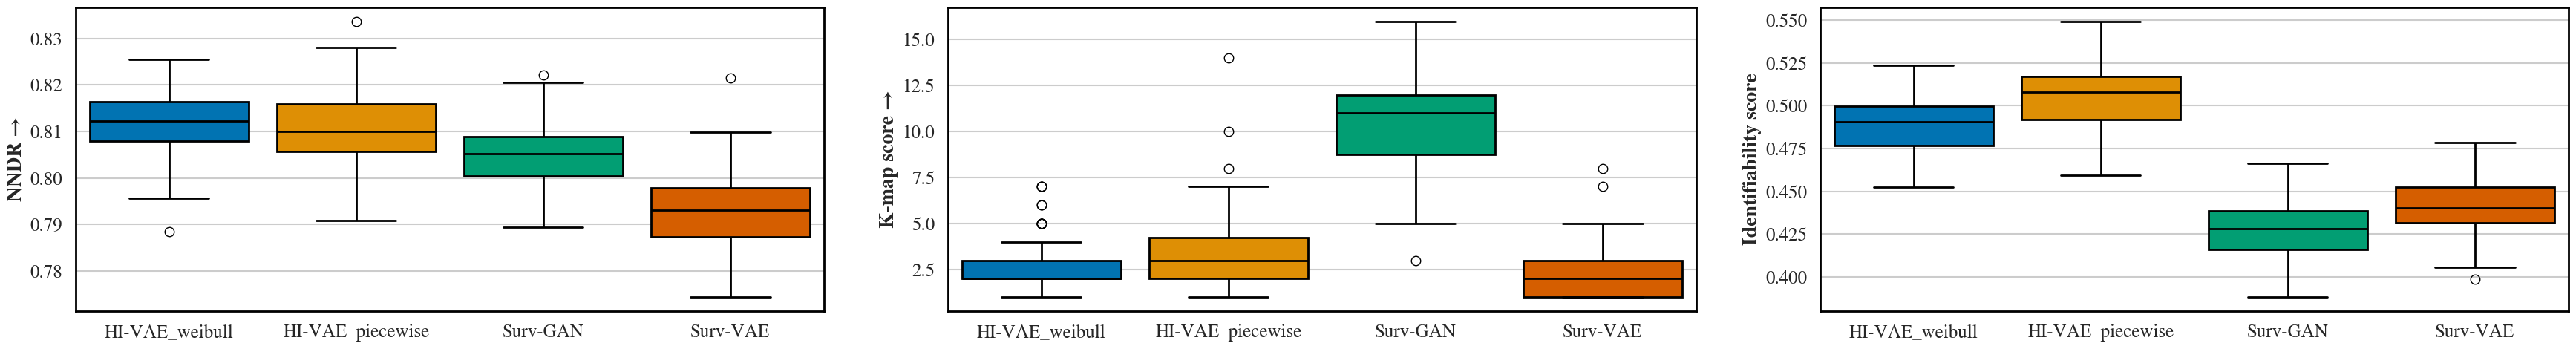

In [ ]:
privacy_metrics = [['NNDR', "max"], ['K-map score', "max"], ["Identifiability score", 0.5]]

visualize_general_perf(general_scores_full_df, metrics=privacy_metrics, title = "Data sharing case")

visualize_general_perf(general_scores_aug_df, metrics=privacy_metrics, title = "Data augmentation case")

#### 3.1.4 Replicability metrics

In [ ]:
from metrics import replicability_ext
replicability_scores = []
for generator_name in generators_sel:
    replicability_scores.append(replicability_ext(df_init, df_syn_dict[generator_name], generator_name))
replicability_scores_df = pd.concat(replicability_scores, ignore_index=True)

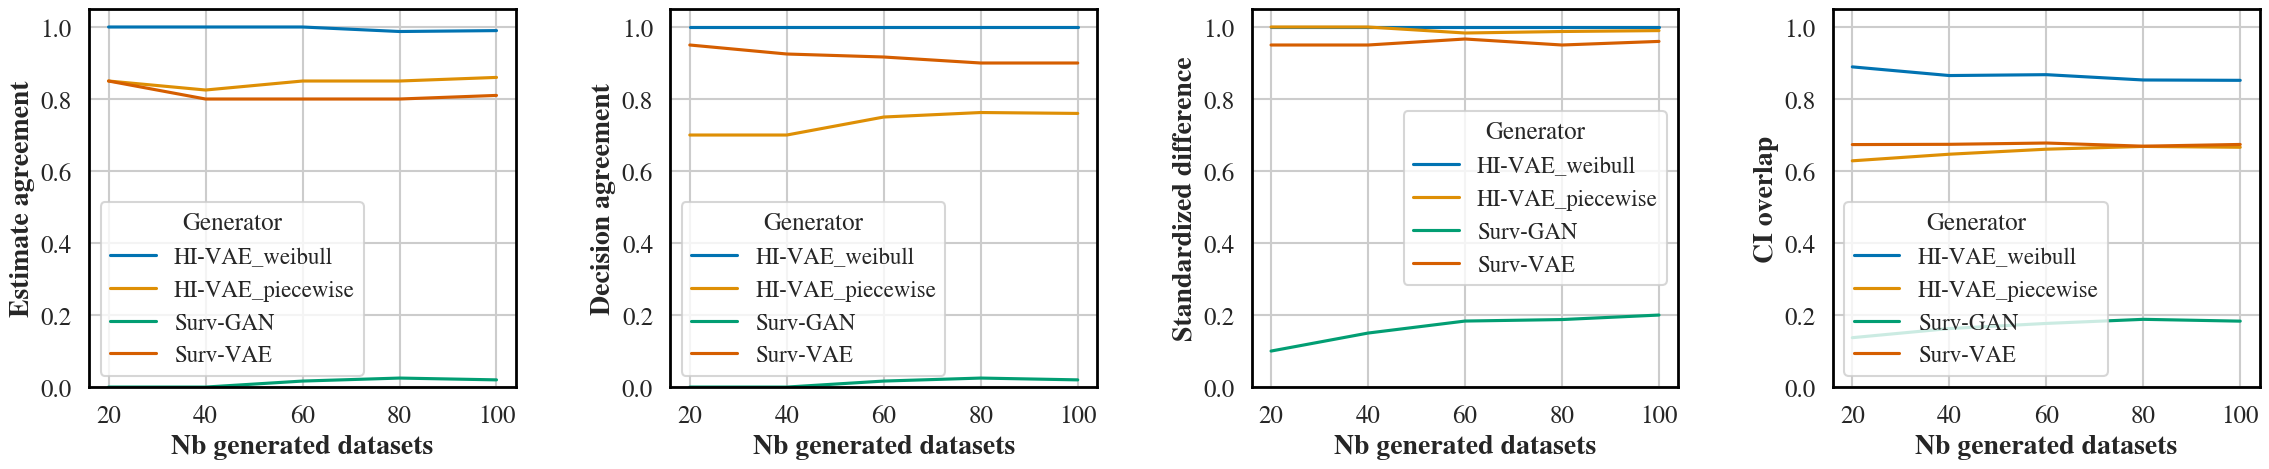

In [ ]:
from visualization import visualize_replicability_perf
visualize_replicability_perf(replicability_scores_df)

In [ ]:
from metrics import fit_cox_model
import numpy as np
columns = ['time', 'censor', 'treatment']
coef_init, _, ci_init, se_init = fit_cox_model(df_init, columns)
# Compute midpoints and widths
midpoints = [(ci_init[1] + ci_init[0]) / 2]
errors = [(ci_init[1] - ci_init[0]) / 2]
label = ["Init"]
colors = ['green', 'blue', 'orange', 'cyan']

colors_ = ['red']
for i , generator in enumerate(generators_sel):
    data_syn_ = df_syn_dict[generator]
    results = [fit_cox_model(data, columns) for data in data_syn_]
    coef_syn, _, _, se_syn = zip(*results)
    for n in range(10):
        coef_syn_, se_syn_ = np.array(coef_syn)[n][0], np.array(se_syn)[n][0]
        ci_syn = (coef_syn_ - 1.96 * se_syn_, coef_syn_ + 1.96 * se_syn_)
        midpoints.append((ci_syn[1] + ci_syn[0]) / 2)
        errors.append((ci_syn[1] - ci_syn[0]) / 2)
        label.append(generator + " " + str(n + 1))
        colors_.append(colors[i])

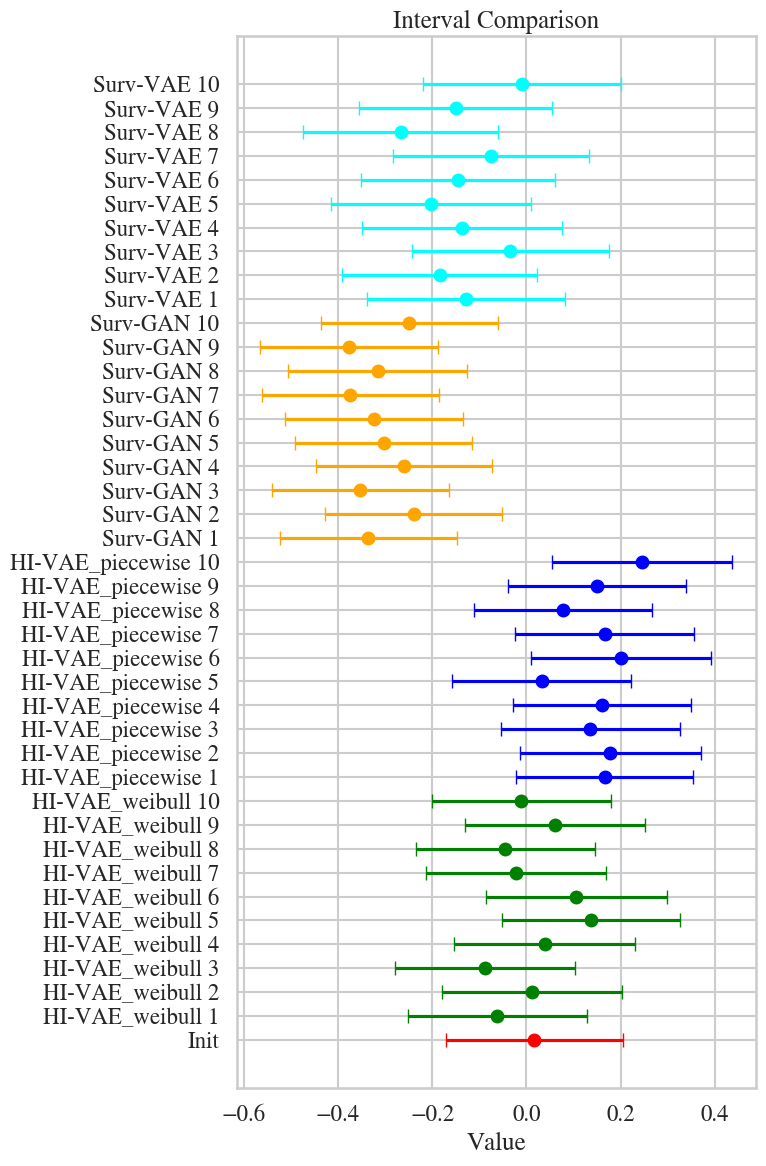

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 12))

# Plot as horizontal error bars
for i, (mid, err) in enumerate(zip(midpoints, errors)):
    ax.errorbar(x=mid, y=i, xerr=err, fmt='o', capsize=5, color=colors_[i])

plt.yticks(range(len(midpoints)), label)
plt.xlabel("Value")
plt.title("Interval Comparison")
plt.grid(True)
plt.tight_layout()
plt.show()

### 3.2. MIA-based metrics

In [ ]:
from metrics import membership_inference_attack

list_mia_scores = []
for generator_name in generators_sel:
    mia_results_dict = membership_inference_attack(df_init_control_train, df_init_control_holdout, dict_model_generated_data_aug[generator_name], categorical=categorical+['censor', 'treatment'], bootstrap=True, return_boot_auc=True)
    mia_score_df = pd.DataFrame()
    mia_score_df['AUC-ROC'] = mia_results_dict['boot_auc']
    mia_score_df['generator'] = generator_name
    mia_score_df['aug_pct'] = 2/3
    mia_score_df['dataset_name'] = dataset_name
    list_mia_scores.append(mia_score_df)
mia_scores_df_complete = pd.concat(list_mia_scores)

In [ ]:
visualize_general_perf(mia_scores_df_complete, metrics=[["AUC-ROC", 0.5]])

### 3.3. Aggregate

#### 3.3.1 Fidelity metrics

In [ ]:
from visualization import visualize_perf_vs_augmentation

fig = visualize_perf_vs_augmentation([general_scores_all_df, mia_scores_df_complete], fidelity_metrics)

#### 3.3.2 Utility metrics

In [ ]:
fig = visualize_perf_vs_augmentation([general_scores_all_df, mia_scores_df_complete], utility_metrics)

#### 3.3.3 Privacy metrics

In [ ]:
fig = visualize_perf_vs_augmentation([general_scores_all_df, mia_scores_df_complete], privacy_metrics+[["AUC-ROC", 0.5]])